In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

In [ ]:
import sqlite3

conn = sqlite3.connect("../bluestock_mf.db")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [5]:
import os
print(os.getcwd())


c:\Users\saide\Mutual_Fund_Analytics\notebooks


In [6]:
print(os.getcwd())



c:\Users\saide\Mutual_Fund_Analytics\notebooks


In [7]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
investor = pd.read_csv("../data/processed/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("✅ All datasets loaded successfully!")


✅ All datasets loaded successfully!


In [8]:
print(nav_history.columns)


Index(['amfi_code', 'date', 'nav'], dtype='str')


In [9]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Plot daily NAV for all schemes
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()


In [10]:
print(nav_history.head())


   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [11]:
import plotly.io as pio

pio.renderers.default = "browser"

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

In [12]:
print(aum.columns)


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [13]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Check the first few rows
print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


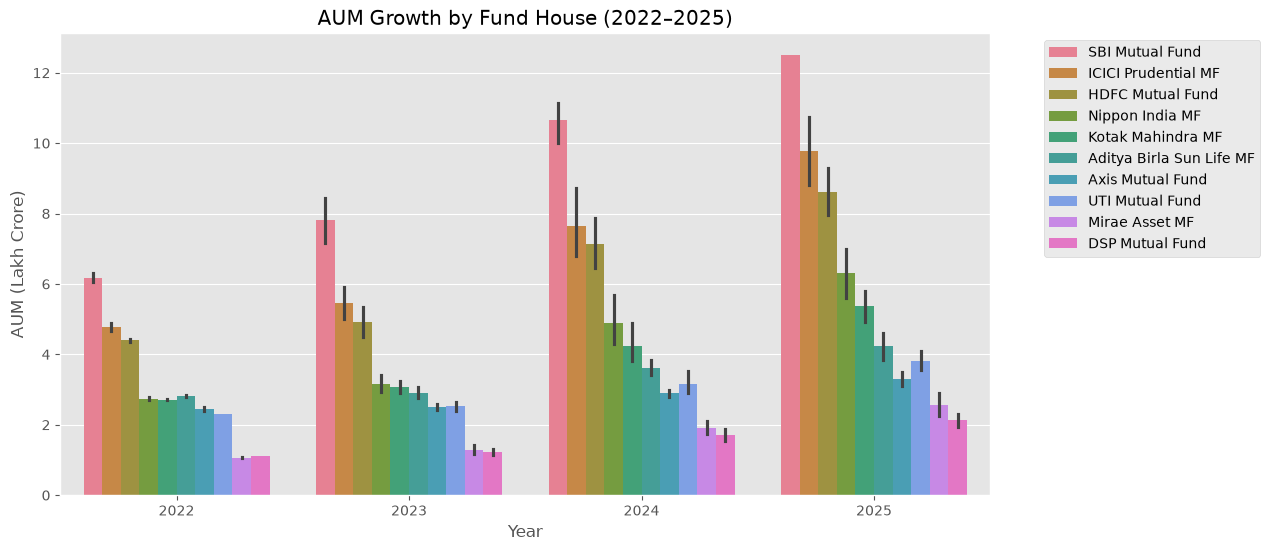

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Increase figure size
plt.figure(figsize=(12, 6))

# Create grouped bar chart
sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Chart title and labels
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

# Show legend
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Show chart
plt.show()



In [15]:
print(sip.columns)



Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [16]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create interactive line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (Jan 2022 – Dec 2025)",
    markers=True
)

# Highlight the highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'Highest: ₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2
)

fig.show()

In [17]:
print(category.columns)


Index(['month', 'category', 'net_inflow_crore'], dtype='str')


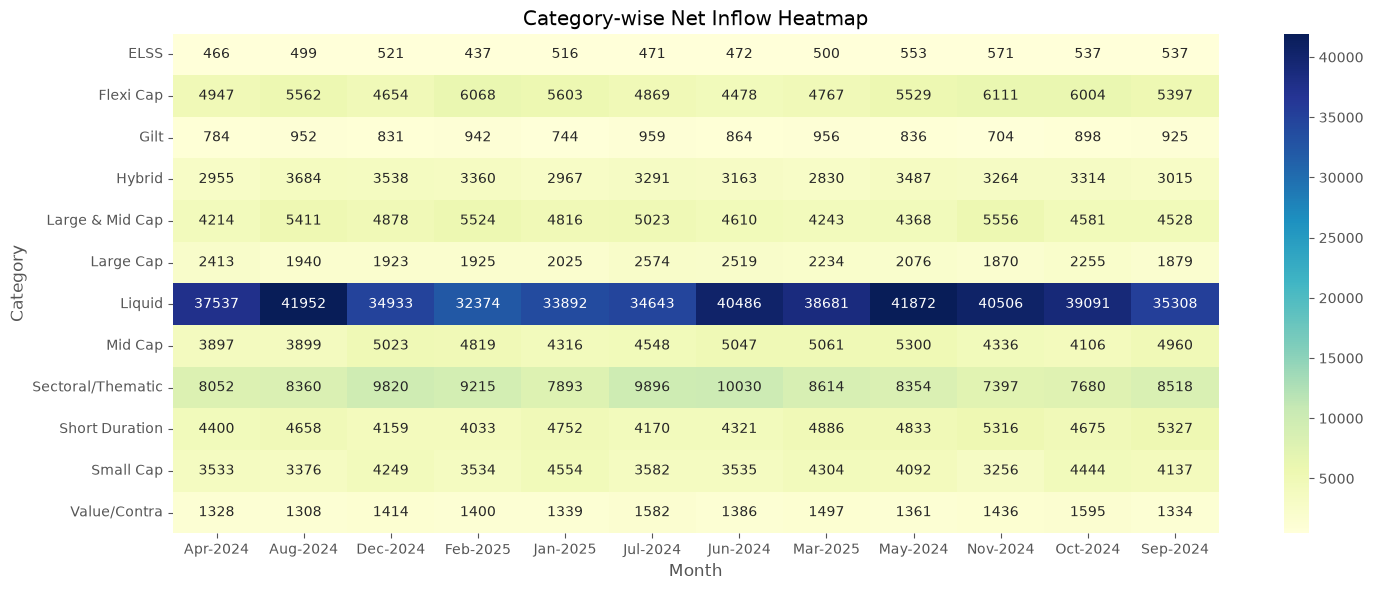

In [18]:
# Convert month column to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert month to Month-Year format
category["month_name"] = category["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month_name",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


In [19]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


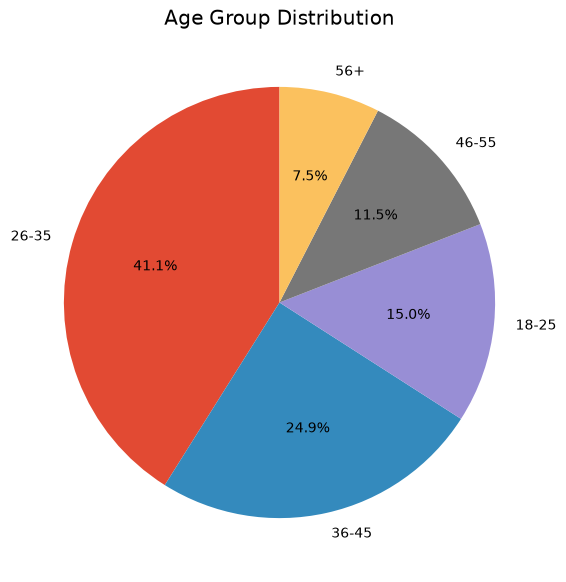

In [20]:
# Age Group Distribution Pie Chart

plt.figure(figsize=(7,7))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

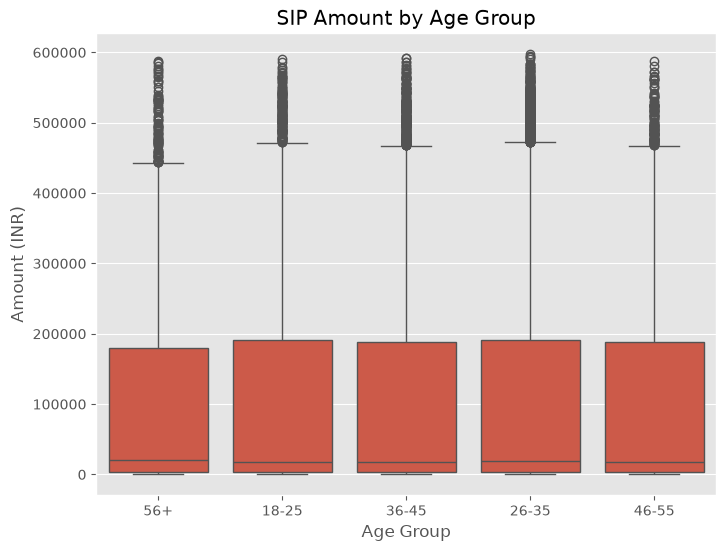

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.show()

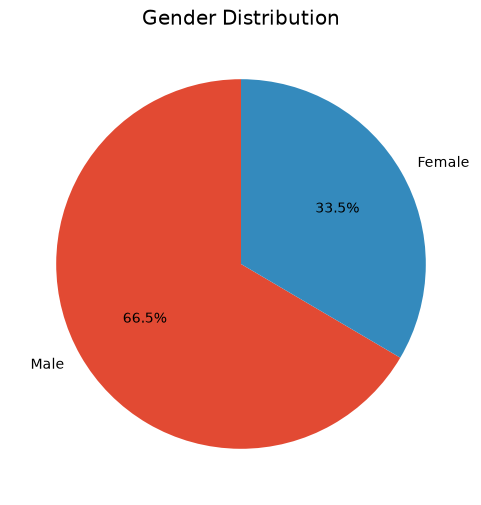

In [22]:
plt.figure(figsize=(6,6))

investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

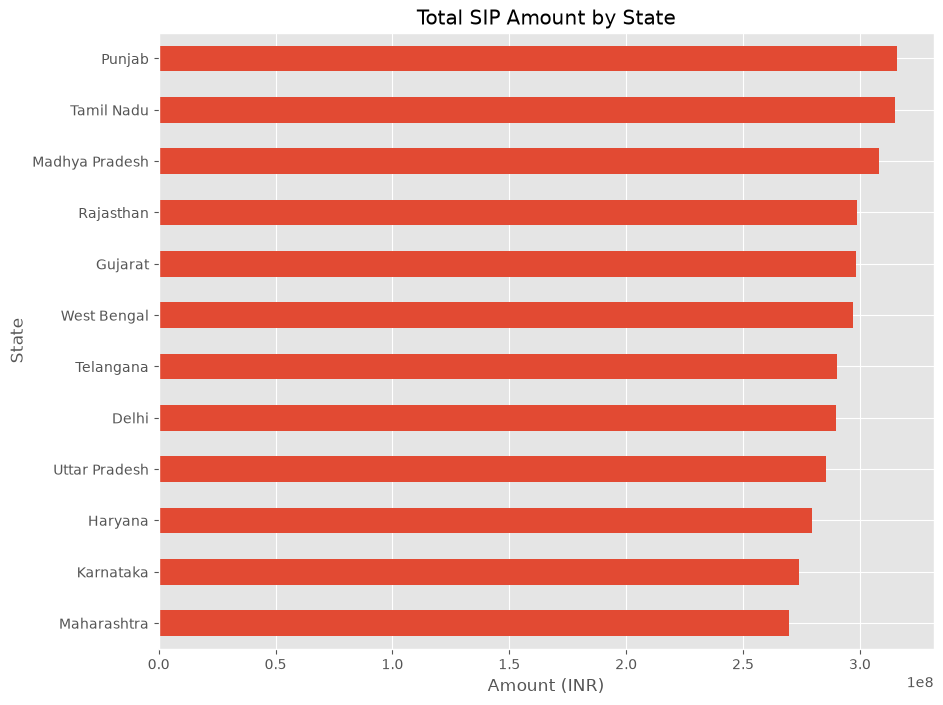

In [23]:
# Total SIP amount by state
state_data = investor.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.show()

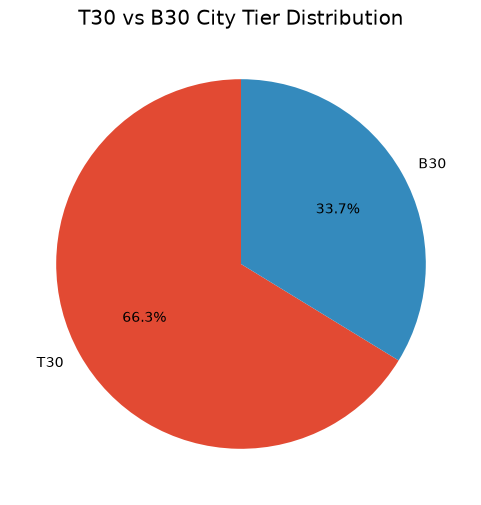

In [24]:
plt.figure(figsize=(6,6))

investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")

plt.show()

In [25]:
print(folio.columns)


Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [26]:
# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Create line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Growth of Mutual Fund Folios (2022–2025)",
    markers=True
)

# Mark the first value (around 13.26 Cr)
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text=f'Start: {folio.iloc[0]["total_folios_crore"]:.2f} Cr',
    showarrow=True
)

# Mark the last value (around 26.12 Cr)
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text=f'End: {folio.iloc[-1]["total_folios_crore"]:.2f} Cr',
    showarrow=True
)

fig.show()

In [27]:
print(nav_history.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [28]:
print(nav_history["amfi_code"].nunique())

40


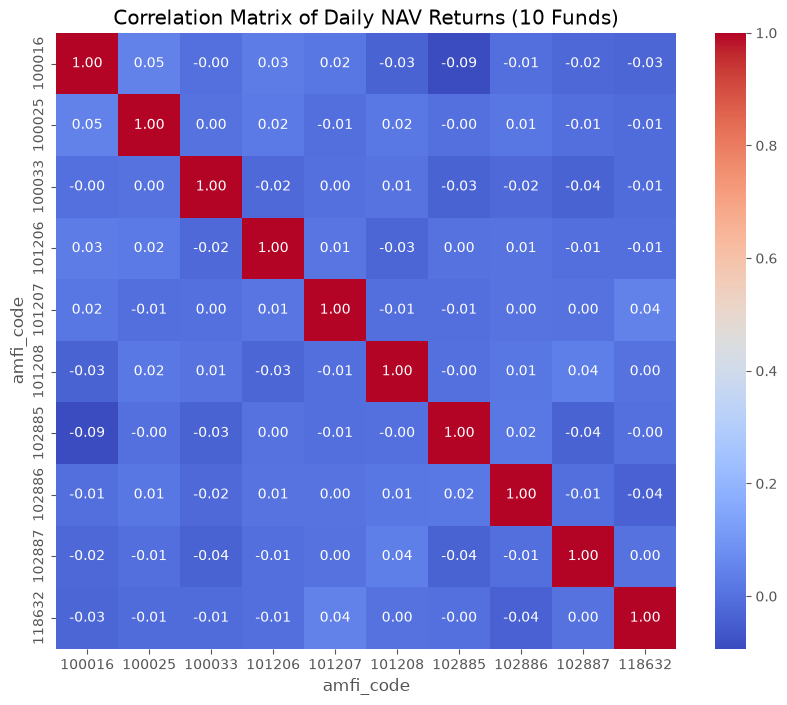

In [29]:
# Create a wide table: rows = dates, columns = fund codes
pivot_nav = nav_history.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
daily_returns = pivot_nav.pct_change().dropna()

# Select first 10 funds
selected_returns = daily_returns.iloc[:, :10]

# Correlation matrix
corr_matrix = selected_returns.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")
plt.show()

In [30]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [31]:
# Aggregate sector weights
sector_data = portfolio.groupby("sector")["weight_pct"].sum().reset_index()

# Create Donut Chart
fig = px.pie(
    sector_data,
    names="sector",
    values="weight_pct",
    title="Sector Allocation Across Equity Funds",
    hole=0.5
)

fig.show()

# Key EDA Findings

1. Daily NAV values generally increased during 2023, indicating a strong market trend.
2. A market correction is visible during 2024 across multiple mutual fund schemes.
3. SBI Mutual Fund recorded the highest Assets Under Management (AUM).
4. SIP inflows steadily increased and reached their peak in late 2025.
5. Equity-oriented categories received higher net inflows than most other categories.
6. Investors in the 26–35 age group contributed the highest number of investments.
7. The gender distribution of investors is relatively balanced.
8. T30 cities contributed a larger share of investments compared to B30 cities.
9. Total mutual fund folios increased consistently from 2022 to 2025.
10. Most selected mutual funds showed a positive correlation in daily NAV returns.
